In [1]:
import os
import yaml
import re 

import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.patheffects as pe
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.animation import PillowWriter
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion

import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

In module 'Darwin':
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/libkern/arm/OSByteOrder.h:14:1: error: '_OSSwapInt16' has different definitions in different modules; definition in module 'Darwin.libkern.OSByteOrder' first difference is return type is 'uint16_t' (aka 'unsigned short')
uint16_t
^~~~~~~~
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/libkern/arm/_OSByteOrder.h:49:1: note: but in 'DarwinFoundation.OSByteOrder' found different return type '__uint16_t' (aka 'unsigned short')
__uint16_t
^~~~~~~~~~
In module 'Darwin':
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/libkern/arm/OSByteOrder.h:24:1: error: '_OSSwapInt32' has different definitions in different modules; definition in module 'Darwin.libkern.OSByteOrder' first difference is return type is 'uint32_t' (aka 'unsigned int')
uint32_t
^~~~~~~~
/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/libkern/arm/_OSByteOrder.h:59:1: note: but in 'DarwinFoundation.O

Welcome to JupyROOT 6.30/04


07:25:00 WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=273590;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=428820;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=850536;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=285162;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=218834;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=737460;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=768745;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=101360;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=189258;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=704896;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=185939;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=738790;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=996374;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=117890;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=216609;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=155772;file:///Users/rishi/Documents/Analysis/miniconda3/envs/astro_hal/lib/python3.9/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [7]:
# filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.5.fits.gz'
filename = '/Users/rishi/Documents/Analysis/palmer/aerie-apps_bin4-9__allsky_1024_i2.5_r0.0_p1.0.fits.gz'
x = 53
y = 0
xlength = 3
ylength = 2
coord_sys = 'G'

array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

ROI center in Galactic Coordintes = 53, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 53.0 0.0 
CRPIX : 540.0 360.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1080  720
Fits File loaded
Degrees per pixel: 0.005555555555555556 


x 2.72516000e+02  -1.9416700e+01 x G11.0-0.0
x 2.72445800e+02  -1.9200000e+01 x G11.1+0.1
x 2.72429200e+02  -1.9304700e+01 x PSR J1809-1917
x 2.72870800e+02  -1.9423600e+01 x PSR J1811-1925
x 2.72862500e+02  -1.9416700e+01 x G11.2-0.3
x 2.72695800e+02  -1.9083300e+01 x G11.4-0.1

In [56]:
names = ['G11.1+0.1', 'G11.2-0.3', 'G11.4-0.1', 'G11.0-0.0', 'PSR J1809-1917', 'PSR J1811-1925']
ra = [272.4458, 272.8625, 272.695, 272.516, 272.429, 272.875]
dec = [-19.2, -19.416, -19.0833, -19.4167, -19.304, -19.423]
radius = [0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
source = pd.DataFrame({
    "Name": names, 
    "ra": ra,
    "dec": dec, 
    "ext": radius,
    })


In [62]:
names = [ 'PSR J1809-1917', 'PSR J1811-1925']
ra = [ 272.429, 272.875]
dec = [ -19.304, -19.423]
radius = [ 0.01, 0.01]
source = pd.DataFrame({
    "Name": names, 
    "ra": ra,
    "dec": dec, 
    "ext": radius,
    })


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


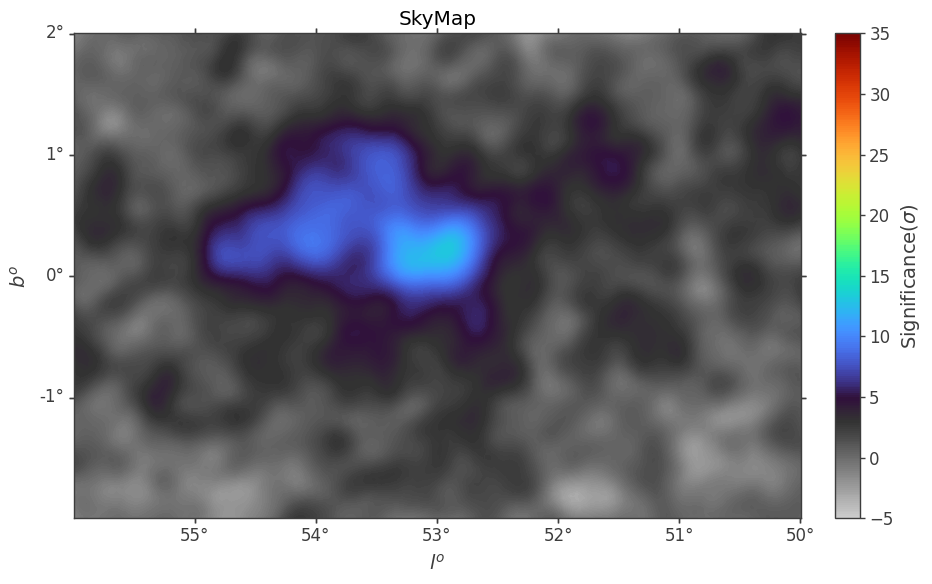

In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

source = None
fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', threshold=4, vmin=-5, vmax=35, contour=False, title='SkyMap', hotspots=source, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4sfgl', 'pualsar', '4haawc', '1lhaaaso'])

In [2]:
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.5.fits.gz'
# x = 285.5577500    
# y = 6.8755333
# xlength = 3
# ylength = 3
# coord_sys = 'C'
x = 45
y = 0
xlength = 3
ylength = 3
coord_sys = 'G'
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

ROI center in Galactic Coordintes = 45, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 45.0 0.0 
CRPIX : 540.0 540.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1080  1080
Fits File loaded
Degrees per pixel: 0.005555555555555556 


In [11]:
names = ['1LHAASO J1902+0648', 'HAWC J1902+0655']
ra = [285.58, 285.55]
dec = [6.80, 6.927]
radius = [0.15, 0.01]
source = pd.DataFrame({
    "Name": names, 
    "ra": ra,
    "dec": dec, 
    "ext": radius,
    })


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Plotting contours [7, 9, 12, 13, 14, 15]


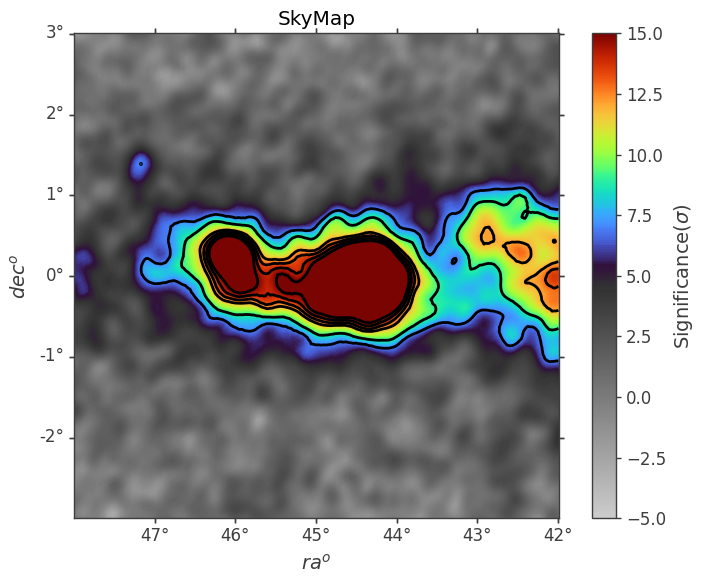

In [4]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
fig, ax = make_plots(array, wcs, pixel_size, coordsys='C', threshold=5, vmin=-5, vmax=15, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4sfgl', 'pualsar', '4haawc', '1lhaaaso'])

In [ ]:
contour_hdu  = fits.open('/Users/rishi/Documents/Analysis/fermifits/fit_model_no4FGLJ1902_pointsource_powerlaw_2.00_tsmap.fits')
contour_header = contour_hdu[0].header
contour_data = contour_hdu[0].data
contour_wcs = WCS(contour_header)

# Transform contour coordinates to match primary WCS
contour_coords = SkyCoord.from_pixel(np.arange(contour_data.shape[1]), np.arange(contour_data.shape[0]), wcs=contour_wcs)
contour_galactic = contour_coords.galactic
contour_x, contour_y = wcs.world_to_pixel(contour_galactic)

# fig
# fig = plt.figure(figsize=(20,8))
# ax = plt.subplot(1,1,1, projection=wcs)#,frame_class=EllipticalFrame)
# im=ax.imshow(array,  cmap=ultimet(vmin=-3, vmax=15, threshold=3), vmin=-3, vmax=15)
# fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')

# levels = np.linspace(5, np.max(sig_data), 15)
levels = [9, 11, 13]
ax.contour(array, levels=levels, colors='black', alpha=1, linewidths=2)

levels2 = np.linspace(5, np.max(contour_data), 5)
hi_transform = ax.get_transform(contour_wcs)

['4FGL J1902.5+0654']
Plotting contours [7, 9, 12, 13, 14, 15]
<SkyCoord (ICRS): (ra, dec) in deg
    (285.58, 6.8)>
<SkyCoord (ICRS): (ra, dec) in deg
    (285.55, 6.927)>


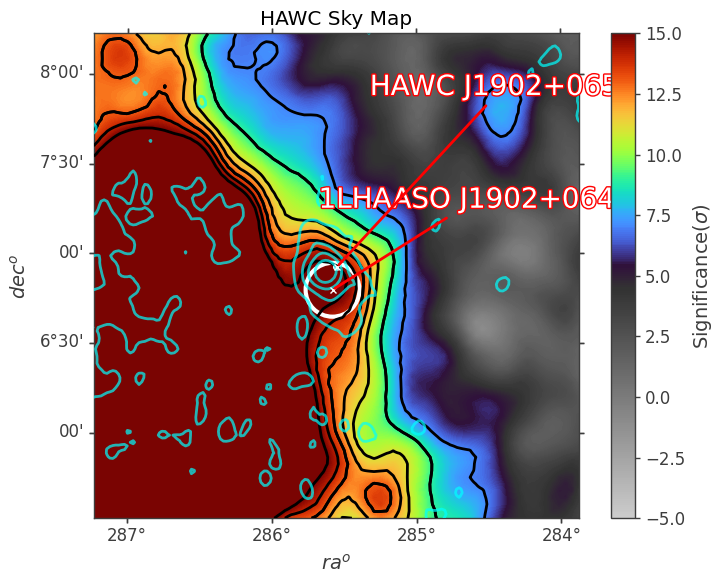

In [34]:
####Plot the full model map with injected source markers
names = ['1LHAASO J1902+0648', 'HAWC J1902+0655']
ra = [285.58, 285.55]
dec = [6.80, 6.927]
ext = [0.15, 0.01]
fermi_name=['4FGL J1902.5+0654']
print(fermi_name)
fig, ax = make_plots(array, wcs, pixel_size, coordsys='C', threshold=5, vmin=-5, vmax=15, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4sfgl', 'pualsar', '4haawc', '1lhaaaso'])
contour_hdu  = fits.open('/Users/rishi/Documents/Analysis/fermifits/fit_model_no4FGLJ1902_pointsource_powerlaw_2.00_tsmap.fits')
contour_header = contour_hdu[0].header
contour_data = contour_hdu[0].data
contour_wcs = WCS(contour_header)

# Transform contour coordinates to match primary WCS
contour_coords = SkyCoord.from_pixel(np.arange(contour_data.shape[1]), np.arange(contour_data.shape[0]), wcs=contour_wcs)
contour_galactic = contour_coords.galactic
contour_x, contour_y = wcs.world_to_pixel(contour_galactic)

levels = [9, 11, 13]
ax.contour(array, levels=levels, colors='black', alpha=1, linewidths=2)

levels2 = np.linspace(5, np.max(contour_data), 5)
hi_transform = ax.get_transform(contour_wcs)
ax.contour(contour_data, levels=levels2, transform=hi_transform, colors='cyan', alpha=0.7)



for i in range(len(names)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = skycoord_to_pixel(coord2, wcs)
    ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
    ax.annotate(names[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(300, (i+1) * 90), 
    textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='red', linewidth=2, 
    linestyle='-'), color='white', rotation=0, ha='right', va='center' ,
    path_effects=[pe.withStroke(linewidth=2, foreground="red")], fontsize=20)
    print(coord2)
    circ= CircleSkyRegion(center=coord2, radius=ext[i]*u.degree)
    circ_pixel = circ.to_pixel(wcs)
    circ_pixel.plot(color='white',label="G012.7-00.0", linewidth=3)

plot_ax_label(ax, coord_sys)
ax.set_title('HAWC Sky Map')
plt.show()


ROI center 292.7, 17
Shape of Map in pixel number: 1440 X 1440
<SkyCoord (ICRS): (ra, dec) in deg
    (292.79, 16.9)>
<SkyCoord (ICRS): (ra, dec) in deg
    (292.81, 16.92)>


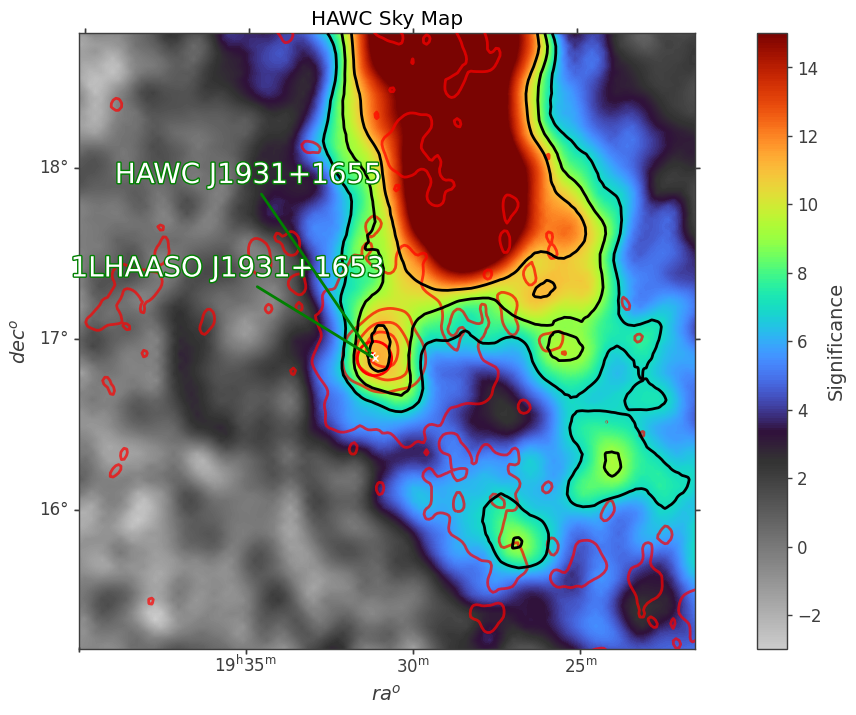

In [57]:
# Load the Simulation FITS file
# filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'

ra_center = 292.7
dec_center = 17

print(f"ROI center {ra_center}, {dec_center}")

coord_sys = 'C'
xlength=4
ylength=4

#Define ROIz
origin = [ra_center, dec_center, xlength, ylength] 
ra_center = "{:.2f}".format(ra_center)
dec_center = "{:.2f}".format(dec_center)

# array, footprint, wcs = loadmap(filename, coord_sys, origin, 'origin')
xnum = array.shape[0]
ynum = array.shape[1]
print(f'Shape of Map in pixel number: {xnum} X {ynum}')



####Plot the full model map with injected source markers
names = ['1LHAASO J1931+1653', 'HAWC J1931+1655']
ra = [292.79, 292.81]
dec = [16.9, 16.92]
ext = [0.1, 0.01]

# Load the contour FITS file
contour_hdu = fits.open('/Users/rishi/Documents/Analysis/fermifits/fit_model_no4FGLJ1931_pointsource_powerlaw_2.00_tsmap.fits')
# contour_hdu  = fits.open('/lustre/hawcz01/scratch/userspace/rbabu/make-hal-great-again/astro-source-detection/fit_model_no4FGLJ1902_pointsource_powerlaw_2.00_tsmap.fits')
contour_header = contour_hdu[0].header
contour_data = contour_hdu[0].data
contour_wcs = WCS(contour_header)

# Transform contour coordinates to match primary WCS
contour_coords = SkyCoord.from_pixel(np.arange(contour_data.shape[1]), np.arange(contour_data.shape[0]), wcs=contour_wcs)
contour_galactic = contour_coords.galactic
contour_x, contour_y = wcs.world_to_pixel(contour_galactic)

fig = plt.figure(figsize=(20,8))
ax = plt.subplot(1,1,1, projection=wcs)#,frame_class=EllipticalFrame)
im=ax.imshow(array,  cmap=ultimet(vmin=-3, vmax=15, threshold=3), vmin=-3, vmax=15)
# im=ax.imshow(array,  cmap=parula_cmap(), vmin=-3, vmax=25)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
plot_ax_label(ax, coord_sys)
# custom_sources_plot(names, ra, dec, ext, ax, wcs)

levels = np.linspace(5, np.max(contour_data), 5)
hi_transform = ax.get_transform(contour_wcs)
ax.contour(contour_data, levels=levels, transform=hi_transform, colors='red', alpha=0.7, linewidths=2)

levels2 = [7,9,11]
hi_transform2 = ax.get_transform(wcs)
ax.contour(array, levels=levels2, transform=hi_transform2, colors='black', linewidth=3)

fermi_name=['4FGL J1931.1+1656']

for i in range(len(names)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = skycoord_to_pixel(coord2, wcs)
    ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
    ax.annotate(names[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(10, (i+1) * 90), 
    textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
    linestyle='-'), color='white', rotation=0, ha='right', va='center' ,
    path_effects=[pe.withStroke(linewidth=2, foreground="green")], fontsize=20)
    print(coord2)
    circ= CircleSkyRegion(center=coord2, radius=ext[i]*u.degree)
    circ_pixel = circ.to_pixel(wcs)
    circ_pixel.plot(color='red',label="G012.7-00.0", linewidth=2)

# fermi_ra = comparison_table["source_ra"].value[0]
# fermi_dec = comparison_table["source_dec"].value[0]
# fermi_ext = comparison_table["semi-major"].value[0]
# for i in range(len(fermi_name)):
#     coord2 = SkyCoord(ra=fermi_ra[i]*u.deg, dec=fermi_dec[i]*u.deg)
#     pixelcoord = utils.skycoord_to_pixel(coord2, wcs)
#     ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
#     ax.annotate(fermi_name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(10, -90), 
#     textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='blue', linewidth=2, 
#     linestyle='-'), color='white', rotation=0, ha='right', va='center' ,
#     path_effects=[pe.withStroke(linewidth=2, foreground="blue")], fontsize=20)
#     print(coord2)
#     circ= CircleSkyRegion(center=coord2, radius=fermi_ext[i]*u.degree)
#     circ_pixel = circ.to_pixel(wcs)
#     circ_pixel.plot(color='blue',label="G012.7-00.0", linewidth=3)
plot_ax_label(ax, coord_sys)


ax.set_title('HAWC Sky Map')
plt.show()
plt.close(fig)

In [68]:
# Load the Simulation FITS file
# filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'

ra_center = 307
dec_center = 37

print(f"ROI center {ra_center}, {dec_center}")

coord_sys = 'C'
xlength=4
ylength=4

#Define ROIz
origin = [ra_center, dec_center, xlength, ylength] 
ra_center = "{:.2f}".format(ra_center)
dec_center = "{:.2f}".format(dec_center)

# array, footprint, wcs = loadmap(filename, coord_sys, origin, 'origin')
xnum = array.shape[0]
ynum = array.shape[1]
print(f'Shape of Map in pixel number: {xnum} X {ynum}')



####Plot the full model map with injected source markers
names = ['1LHAASO J2027+3657']
ra = [306.88]
dec = [36.95]
ext = [0.23]

# Load the contour FITS file
contour_hdu = fits.open('/Users/rishi/Documents/Analysis/fermifits/fit_model_noJ2026_pointsource_powerlaw_2.00_tsmap.fits')
# contour_hdu  = fits.open('/lustre/hawcz01/scratch/userspace/rbabu/make-hal-great-again/astro-source-detection/fit_model_no4FGLJ1902_pointsource_powerlaw_2.00_tsmap.fits')
contour_header = contour_hdu[0].header
contour_data = contour_hdu[0].data
contour_wcs = WCS(contour_header)

# Transform contour coordinates to match primary WCS
contour_coords = SkyCoord.from_pixel(np.arange(contour_data.shape[1]), np.arange(contour_data.shape[0]), wcs=contour_wcs)
contour_galactic = contour_coords.galactic
contour_x, contour_y = wcs.world_to_pixel(contour_galactic)

fig = plt.figure(figsize=(20,8))
ax = plt.subplot(1,1,1, projection=wcs)#,frame_class=EllipticalFrame)
im=ax.imshow(array,  cmap=ultimet(vmin=-3, vmax=15, threshold=3), vmin=-3, vmax=15)
# im=ax.imshow(array,  cmap=parula_cmap(), vmin=-3, vmax=25)
fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='Significance')
plot_ax_label(ax, coord_sys)
# custom_sources_plot(names, ra, dec, ext, ax, wcs)

levels = np.linspace(5, np.max(contour_data), 5)
hi_transform = ax.get_transform(contour_wcs)
ax.contour(contour_data, levels=levels, transform=hi_transform, colors='white', alpha=0.7, linewidths=2)

levels2 = [7,9,11]
hi_transform2 = ax.get_transform(wcs)
ax.contour(array, levels=levels2, transform=hi_transform2, colors='black', linewidth=3)

fermi_name=['4FGL J1931.1+1656']

for i in range(len(names)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = skycoord_to_pixel(coord2, wcs)
    ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
    ax.annotate(names[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(10, (i+1) * 90), 
    textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
    linestyle='-'), color='white', rotation=0, ha='right', va='center' ,
    path_effects=[pe.withStroke(linewidth=2, foreground="green")], fontsize=20)
    print(coord2)
    circ= CircleSkyRegion(center=coord2, radius=ext[i]*u.degree)
    circ_pixel = circ.to_pixel(wcs)
    circ_pixel.plot(color='red',label="G012.7-00.0", linewidth=2)

# fermi_ra = comparison_table["source_ra"].value[0]
# fermi_dec = comparison_table["source_dec"].value[0]
# fermi_ext = comparison_table["semi-major"].value[0]
# for i in range(len(fermi_name)):
#     coord2 = SkyCoord(ra=fermi_ra[i]*u.deg, dec=fermi_dec[i]*u.deg)
#     pixelcoord = utils.skycoord_to_pixel(coord2, wcs)
#     ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
#     ax.annotate(fermi_name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(10, -90), 
#     textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='blue', linewidth=2, 
#     linestyle='-'), color='white', rotation=0, ha='right', va='center' ,
#     path_effects=[pe.withStroke(linewidth=2, foreground="blue")], fontsize=20)
#     print(coord2)
#     circ= CircleSkyRegion(center=coord2, radius=fermi_ext[i]*u.degree)
#     circ_pixel = circ.to_pixel(wcs)
#     circ_pixel.plot(color='blue',label="G012.7-00.0", linewidth=3)
plot_ax_label(ax, coord_sys)


ax.set_title('HAWC Sky Map')
# plt.show()
plt.savefig('/Users/rishi/Documents/Analysis/fermifits/1LHAASOJ2027+3657_sky_map.svg')#, dpi=300)
plt.close(fig)

ROI center 307, 37
Shape of Map in pixel number: 1440 X 1440
<SkyCoord (ICRS): (ra, dec) in deg
    (306.88, 36.95)>


Filename: /Users/rishi/Documents/Analysis/2027/Gas/j2027+3657_-10_5km-s.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      47   (80, 81)   float32   
<SkyCoord (ICRS): (ra, dec) in deg
    (306.88, 36.95)>


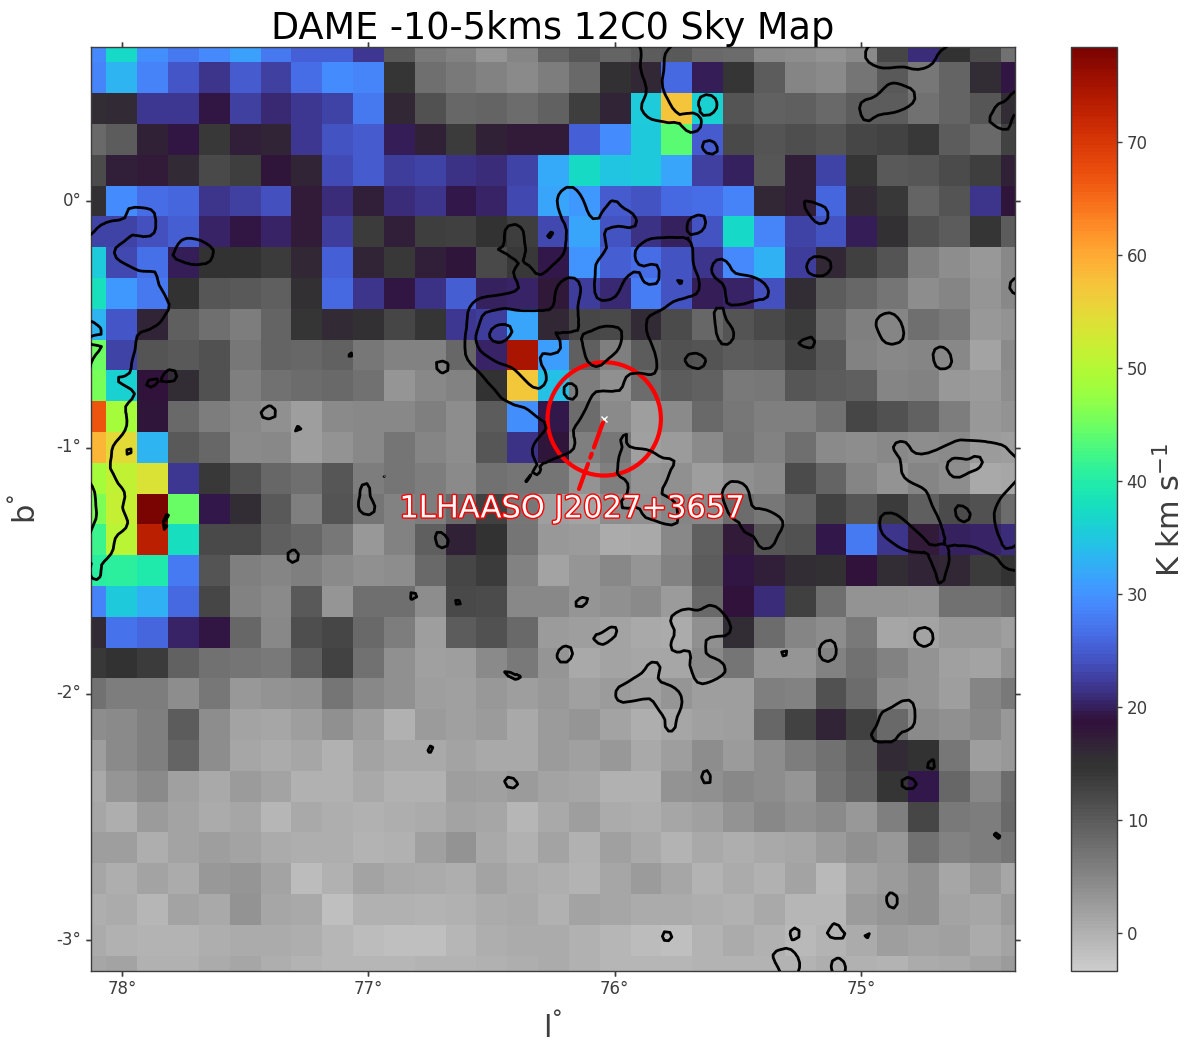

In [106]:
import matplotlib.pyplot as plt
# plt.rcParams.update({'font.size': 22})
plt.rcParams['font.size'] = 22  # Sets the default font size for all text elements
plt.rcParams['axes.labelsize'] = 22 # Sets the font size for axis labels
plt.rcParams['xtick.labelsize'] = 12 # Sets the font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12
file = fits.open('/Users/rishi/Documents/Analysis/2027/Gas/j2027+3657_-10_5km-s.fits')
file.info()
gsig_data = file[0].data
header = file[0].header
# print(sig_data.shape)
# wcs2=WCS(header)

# Convert ICRS to Galactic
wcs3 = WCS(header)

# Load the contour FITS file
contour_hdu = fits.open('/Users/rishi/Documents/Analysis/fermifits/fit_model_noJ2026_pointsource_powerlaw_2.00_tsmap.fits')
# contour_hdu  = fits.open('/lustre/hawcz01/scratch/userspace/rbabu/make-hal-great-again/astro-source-detection/fit_model_no4FGLJ1902_pointsource_powerlaw_2.00_tsmap.fits')
contour_header = contour_hdu[0].header
contour_data = contour_hdu[0].data
contour_wcs = WCS(contour_header)

# Transform contour coordinates to match primary WCS
contour_coords = SkyCoord.from_pixel(np.arange(contour_data.shape[1]), np.arange(contour_data.shape[0]), wcs=contour_wcs)
contour_galactic = contour_coords.galactic
contour_x, contour_y = wcs.world_to_pixel(contour_galactic)



fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection=wcs3)
# filtered_arr=gaussian_filter(gsig_data, 0.5)
img = ax.imshow(gsig_data, cmap=ultimet(vmin=0, vmax=80, threshold=20))#, vmax=25) #coolwarm∂
plt.colorbar(img, ax=ax, label=r"K km s$^{-1}$", fraction=0.046, pad=0.04)
# img.set_clim(0,10)
levels = np.linspace(5, np.max(contour_data), 5)
hi_transform = ax.get_transform(contour_wcs)
ax.contour(contour_data, levels=levels, transform=hi_transform, colors='black')

for i in range(len(names)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = skycoord_to_pixel(coord2, wcs3)
    ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
    ax.annotate(names[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(140, -90), 
    textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='red', linewidth=3, 
    linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
    path_effects=[pe.withStroke(linewidth=2, foreground="red")])
    print(coord2)
    circ= CircleSkyRegion(center=coord2, radius=ext[i]*u.degree)
    circ_pixel = circ.to_pixel(wcs3)
    circ_pixel.plot(color='red',label="G012.7-00.0", linewidth=3)

ax.set_xlabel(r"l$^{\degree}$")
ax.set_ylabel(r"b$^{\degree}$")
ax.set_title('DAME -10-5kms 12C0 Sky Map')
ax.set_xlim(15, 45)
ax.set_ylim(15, 45)
plt.show()
# plt.savefig('/Users/rishi/Documents/Analysis/fermifits/1LHAASOJ2027+3657_dame_co_map.svg')#, dpi=300)
plt.close(fig)
# plt.grid(False, which='both')


Filename: /Users/rishi/Documents/Analysis/data/Hermes-allchan-wH2-large.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (800, 800, 10)   float64   
(10, 800, 800)
['', '', '']
3 3
<SkyCoord (ICRS): (ra, dec) in deg
    (304.89, 36.76)>
(array(599.65195359), array(424.42812842))
306.88 36.949999999999996


(150.0, 650.0)

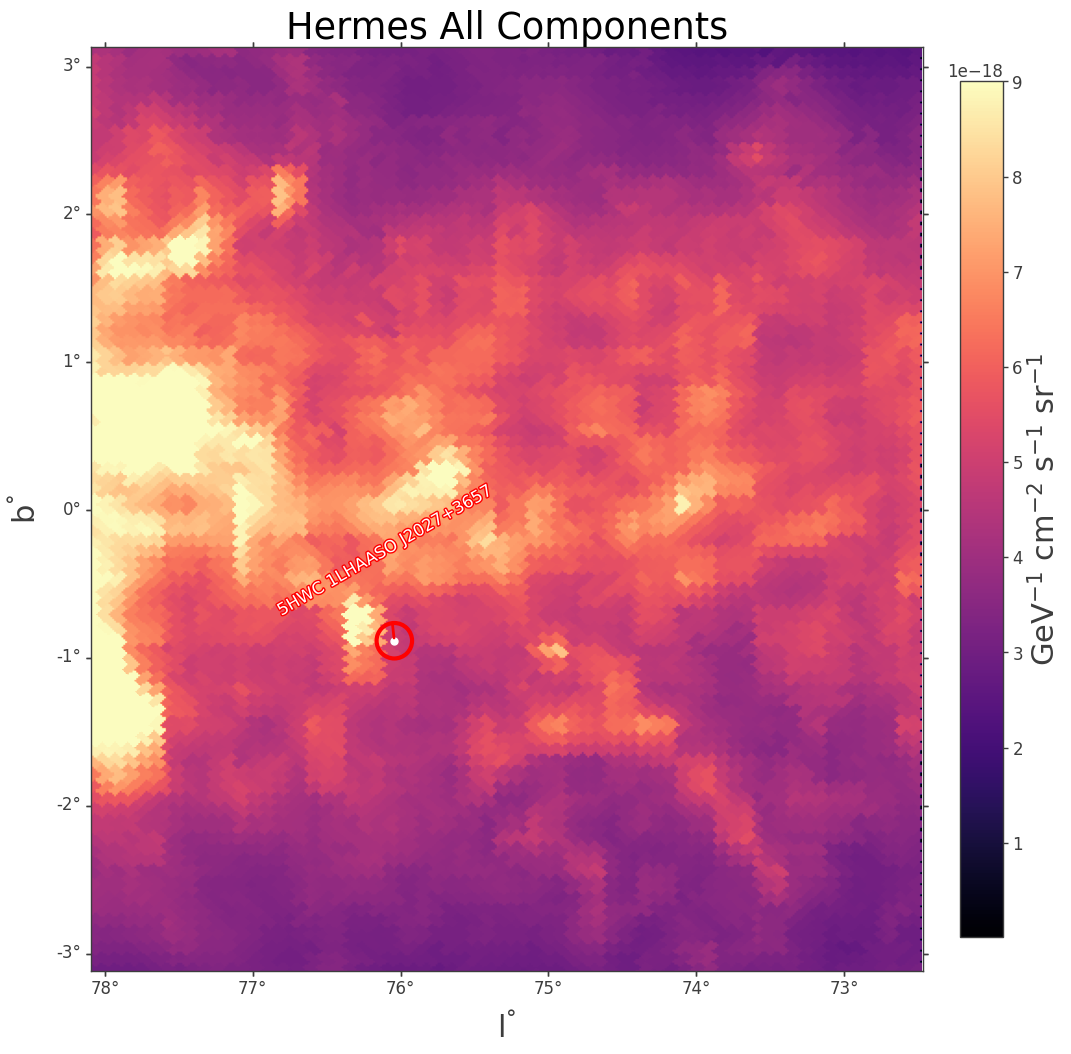

In [126]:
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import skycoord_to_pixel
import matplotlib.patheffects as pe
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits
import matplotlib.cm as cm
file = fits.open('/Users/rishi/Documents/Analysis/data/Hermes-allchan-wH2-large.fits.gz')
file.info()
sig_data = file[0].data
header = file[0].header
print(sig_data.shape)


wcs2 = WCS(header)
c = SkyCoord(wcs2.wcs.crval[0], wcs2.wcs.crval[1], frame='icrs', unit='deg')
galactic = c.galactic

header['CTYPE1'] = 'GLON-CAR'
header['CTYPE2'] = 'GLAT-CAR'
header['CRVAL1'] = galactic.l.deg
header['CRVAL2'] = galactic.b.deg

print(wcs2.world_axis_names)
print(wcs2.pixel_n_dim, wcs2.world_n_dim)

wcs2_celestial = wcs2.celestial
roi_center = SkyCoord(ra=304.89*u.deg, dec=36.76*u.deg, frame='icrs')
print(roi_center)
center_pixel = skycoord_to_pixel(roi_center, wcs2_celestial)

print(center_pixel)
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection=wcs2, slices=('x', 'y', 1))
im = ax.imshow(sig_data[1, :, :], cmap='magma', vmin=1e-20, vmax=9e-18)
fig.colorbar(im,fraction=0.046, pad=0.04, label=r"GeV$^{-1}$ cm$^{-2}$ s$^{-1}$ sr$^{-1}$")


# center_pixel = wcs2.world_to_pixel(roi_center)
a_1sigma = 0.36
e = 0.8348
theta = 19.9    
b_1sigma = a_1sigma * np.sqrt(1 - e**2)
ra_roi = roi_center.icrs.ra.value
dec_roi = roi_center.icrs.dec.value
pix_scale_x = np.abs(wcs2.wcs.cdelt[0]) 
pix_scale_y = np.abs(wcs2.wcs.cdelt[1]) 

names = [ '1LHAASO J2027+3657', 'J2026_3880']
ra = [3.0688, 3.0699]
dec = [3.695,3.7301]
ext = [.12 ,.01]
ra = [100 * i for i in ra]
dec = [10 * i for i in dec]
names = [ '1LHAASO J2027+3657']
ra = [3.0688]
dec = [3.695]
ext = [.12]
ra = [100 * i for i in ra]
dec = [10 * i for i in dec]
color = cm.Greys(np.linspace(0, 1, len(names)))
custom_sources_plot(names, ra, dec, ext, ax, wcs2, pix_scale_x)
ax.set_title("Hermes All Components")
ax.set_xlabel(r"l$^{\degree}$")
ax.set_ylabel(r"b$^{\degree}$")
ax.set_xlim(350, 800)
ax.set_ylim(150, 650)
# plt.grid(False, which='both')

Filename: /Users/rishi/Documents/Analysis/fermifits/fit_model_noJ2026_pointsource_powerlaw_2.00_tsmap.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      25   (500, 500)   float64   
  1  TSMAP_DATA    1 BinTableHDU     18   1R x 3C   [32A, D, 32A]   
  2  NPRED_MAP     1 ImageHDU        26   (500, 500)   float64   
  3  N_MAP         1 ImageHDU        26   (500, 500)   float64   
  4  SQRT_TS_MAP    1 ImageHDU        26   (500, 500)   float64   
57.71115290517628
[ 10.  40.  70. 100.]
<SkyCoord (ICRS): (ra, dec) in deg
    (306.88, 36.95)>


(200.0, 300.0)

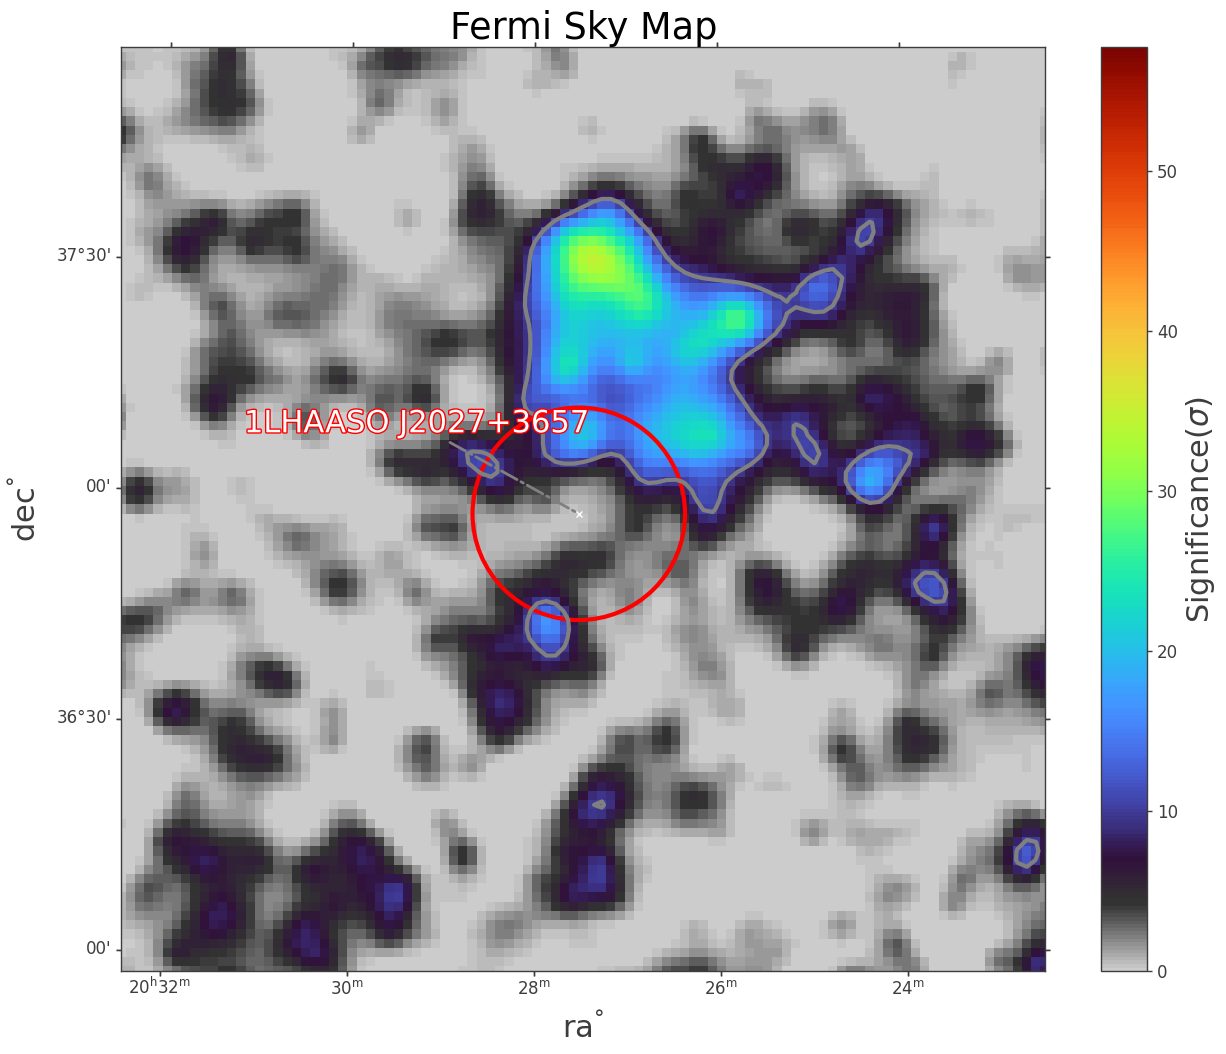

In [112]:
file  = fits.open('/Users/rishi/Documents/Analysis/fermifits/fit_model_noJ2026_pointsource_powerlaw_2.00_tsmap.fits')
file.info()
sig_data = file[0].data
excess_data = file[2].data #excess map
header = file[0].header
print(np.max(sig_data))
# wcs2=WCS(header)

# Convert ICRS to Galactic
wcs2 = WCS(header)

fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection=wcs2)
img = ax.imshow(sig_data, cmap=ultimet(vmin=0, vmax=50, threshold=5))#, vmax=50) #coolwarm∂
plt.colorbar(img, ax=ax, label=r'Significance($\sigma$)', fraction=0.046, pad=0.04)
# img.set_clim(0,10)
fermi_name=['4FGL J2026.5+3718c']
levels = np.linspace(10, 100, 4)
print(levels)
ax.contour(sig_data, levels=levels, colors='gray', alpha=1, linewidths=3)

for i in range(len(names)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = skycoord_to_pixel(coord2, wcs2)
    ax.plot(pixelcoord[0], pixelcoord[1], marker='x', markersize=5, color='white')
    ax.annotate(names[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', xytext=(10, 90), 
    textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='gray', linewidth=2, 
    linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
    path_effects=[pe.withStroke(linewidth=2, foreground="red")])
    print(coord2)
    circ= CircleSkyRegion(center=coord2, radius=ext[i]*u.degree)
    circ_pixel = circ.to_pixel(wcs2)
    circ_pixel.plot(color='red',label="G012.7-00.0", linewidth=3)


ax.set_xlabel(r"ra$^{\degree}$")
ax.set_ylabel(r"dec$^{\degree}$")
ax.set_title('Fermi Sky Map')
ax.set_xlim(200, 300)
ax.set_ylim(200, 300)
# plt.grid(False, which='both')
